# 00631L 五策略對照回測 (2021 ~ 2026)

本 notebook 比較五個進出場策略在同樣資金模型下的年度報酬率，
並提供圖表、交易明細方便解讀。

## 資金模型（五個策略共用）

- 每月月初入金 **20,000** 到資本池（每年至少 240,000）
- **第一批進場**：投入當時資本池 × 0.5
- **第二批加碼**：投入剩餘資本池全部（將資本池歸零）
- **SELL_ALL**：全部持股按當日 close 出場，proceeds 回到資本池
- **進場當日不允許同日出場**，至少留隔一交易日

## 五個策略

| 策略 | 進場觸發（第一批） | 加碼觸發（第二批） | 出場觸發 |
|---|---|---|---|
| **I**   | 收盤 < MA5 | 收盤 < MA20 | 相對均價 ≥ **+7.5%** |
| **II**  | 當日跌幅 > **1%** | 當日跌幅 > **3%** | 相對均價 ≥ **+2%** |
| **III** | 當日跌幅 > **1%** | 當日跌幅 > **3%** | 相對均價 ≥ **+3%** |
| **IV**  | 當日跌幅 > **1.5%** | 當日跌幅 > **3.5%** | 相對均價 ≥ **+2%** |
| **V**   | 當日跌幅 > **1.5%** | 當日跌幅 > **3.5%** | 相對均價 ≥ **+3%** |

### 策略 I：MA-based

- 空手時，若當日收盤價跌破 5 日均線（MA5）→ 用**當時資本池的一半**建立第一批部位（半倉）
- 半倉時，若收盤價續跌破 20 日均線（MA20）→ 用**剩餘資本池全部**加碼第二批（滿倉）
- 有部位時，若 `(close / 持股均價 - 1) ≥ +7.5%` → **全數出場**，回到空手
- 同日連鎖：若當日收盤已同時在 MA5 與 MA20 之下，會同日連進兩批

### 策略 II / III：當日跌幅 1% 進、3% 加

- 空手時，若**今日 close 相對昨日 close 的跌幅 > 1%** → 用資本池的一半進第一批
- 半倉時，若**今日跌幅 > 3%** → 把剩餘資本池全部加碼進第二批
- **策略 II** 出場門檻 +2%；**策略 III** 出場門檻 +3%
- 同日連鎖：若今日跌幅 > 3%（同時也 > 1%），空手一天內連進兩批
- 出場條件用**相對持股均價**的獲利率、不是相對進場價

### 策略 IV / V：當日跌幅 1.5% 進、3.5% 加

- 進出場邏輯同 II / III，只是**進場門檻放寬**：第一批要跌 > 1.5%、第二批要跌 > 3.5%
- **策略 IV** 出場門檻 +2%；**策略 V** 出場門檻 +3%
- 因為進場門檻較嚴，觸發次數會比 II / III 少一些

## 資料

- 讀取 `data/adjusted/00631L.csv`（分割還原後）
- 2026 內部用 adjusted 資料跨分割日連續，避免分割日出現 -95% 假跌


## 1. 環境設定與資料載入

In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd()
project_root = _cwd.parent if _cwd.name == 'notebooks' else _cwd
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei", "Microsoft YaHei", "PingFang TC",
    "Noto Sans TC", "SimHei", "Arial",
]
matplotlib.rcParams["axes.unicode_minus"] = False

from src.backtest import run_backtest
from src.strategy import add_moving_averages, MONTHLY_DEPOSIT

print(f"Project root: {project_root}")
print(f"MONTHLY_DEPOSIT: {MONTHLY_DEPOSIT}")


Project root: D:\Work\00631L
MONTHLY_DEPOSIT: 20000.0


In [2]:
adjusted_path = project_root / "data" / "adjusted" / "00631L.csv"
df = pd.read_csv(adjusted_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
print(f"筆數: {len(df)}, 期間: {df['date'].iloc[0].date()} ~ {df['date'].iloc[-1].date()}")
df.head()


筆數: 2846, 期間: 2014-10-31 ~ 2026-07-09


,date,close
0,2014-10-31,0.918182
1,2014-11-03,0.925455
2,2014-11-04,0.930455
3,2014-11-05,0.922727
4,2014-11-06,0.909545


## 2. 策略 I：MA-based 回測函式（wrapper）

策略 I 直接呼叫專案內現有的 `src.backtest.run_backtest`（每日網頁用的同一份）。
這個 wrapper 只是把結果轉成跟策略 II~V 相同格式，方便對照。


In [3]:
def run_strategy_i(df_ma_full, year_df, monthly_deposit=20000.0):
    """Strategy I on one year, using full history for MA rolling-window warmup."""
    year_start = year_df['date'].iloc[0]
    year_end = year_df['date'].iloc[-1]
    df_for_a = df_ma_full[df_ma_full['date'] <= year_end].reset_index(drop=True)
    result = run_backtest(
        df_for_a, start_date=year_start,
        initial_capital=0.0, monthly_deposit=monthly_deposit,
    )

    df_year = result.df[
        (result.df['date'] >= year_start) & (result.df['date'] <= year_end)
    ].reset_index(drop=True)

    events = []
    for d in result.deposits:
        events.append((d.date, 0, 'deposit', d))
    for t in result.trades:
        events.append((t.date, 1, 'trade', t))
    events.sort(key=lambda e: (e[0], e[1]))

    capital_pool = 0.0
    shares = 0.0
    avg_cost = 0.0
    idx = 0
    daily = []
    for _, row in df_year.iterrows():
        d = row['date']
        while idx < len(events) and events[idx][0] == d:
            _, _, kind, obj = events[idx]
            if kind == 'deposit':
                capital_pool += obj.amount
            else:
                capital_pool = obj.capital_after
                shares = obj.shares_after
                avg_cost = obj.avg_cost_after
            idx += 1
        market_value = shares * row['close'] if shares > 0 else 0.0
        daily.append({
            'date': d, 'close': row['close'],
            'capital_pool': capital_pool, 'shares': shares,
            'avg_cost': avg_cost, 'market_value': market_value,
            'total_assets': capital_pool + market_value,
        })

    total_deposits = sum(d.amount for d in result.deposits)
    end_close = float(df_year.iloc[-1]['close'])
    end_market_value = result.final_shares * end_close
    end_total_assets = result.final_capital_pool + end_market_value

    return {
        'trades': [
            {'date': t.date, 'action': t.action.value, 'price': t.price,
             'invested': t.invested_amount, 'capital_after': t.capital_after}
            for t in result.trades
        ],
        'rounds': [
            {'entry_date': r.entry_date, 'exit_date': r.exit_date,
             'total_invested': r.total_invested, 'total_proceeds': r.total_proceeds,
             'entry_avg_cost': r.entry_avg_price, 'exit_price': r.exit_price,
             'pnl': r.pnl, 'pnl_pct': r.pnl_pct}
            for r in result.rounds
        ],
        'daily': pd.DataFrame(daily),
        'end_capital_pool': result.final_capital_pool,
        'end_shares': result.final_shares,
        'end_avg_cost': result.final_avg_cost,
        'end_close': end_close,
        'end_market_value': end_market_value,
        'end_total_assets': end_total_assets,
        'total_deposits': total_deposits,
        'return_pct': (end_total_assets - total_deposits) / total_deposits * 100
                      if total_deposits > 0 else 0.0,
    }


## 3. 策略 II ~ V：當日單日跌幅回測函式

策略 II ~ V 都用「當日跌幅」觸發，只是參數不同。共用同一個函式，透過參數區分：

- `drop1_pct`：第一批進場門檻
- `drop2_pct`：第二批加碼門檻
- `profit_exit_pct`：獲利出場門檻

註：`drop1_pct` 與 `drop2_pct` 是「跌 X%」的正值百分比（1.0 表示 1%）；
`profit_exit_pct` 也是百分比（2.0 表示 +2%）。


In [4]:
def run_daily_drop_backtest(
    df, drop1_pct, drop2_pct, profit_exit_pct, monthly_deposit=20000.0,
):
    """策略 II ~ V：當日單日跌幅觸發。"""
    df = df.copy().reset_index(drop=True)
    df['prev_close'] = df['close'].shift(1)
    df['drop_pct_today'] = (df['prev_close'] - df['close']) / df['prev_close'] * 100

    capital_pool = 0.0
    shares = 0.0
    avg_cost = 0.0
    position = 'CASH'
    last_deposit_month = None

    trades, rounds, daily_snapshots = [], [], []
    round_entry_date = None
    round_total_invested = 0.0

    for _, row in df.iterrows():
        date = row['date']
        close = row['close']
        drop = row['drop_pct_today'] if pd.notna(row['drop_pct_today']) else 0.0

        ym = (date.year, date.month)
        if ym != last_deposit_month:
            capital_pool += monthly_deposit
            last_deposit_month = ym

        exited_today = False
        if position != 'CASH' and avg_cost > 0:
            if (close / avg_cost - 1) * 100 > profit_exit_pct:
                proceeds = shares * close
                capital_pool += proceeds
                pnl = proceeds - round_total_invested
                pnl_pct = pnl / round_total_invested if round_total_invested else 0.0
                rounds.append({
                    'entry_date': round_entry_date, 'exit_date': date,
                    'total_invested': round_total_invested, 'total_proceeds': proceeds,
                    'entry_avg_cost': avg_cost, 'exit_price': close,
                    'pnl': pnl, 'pnl_pct': pnl_pct,
                })
                trades.append({
                    'date': date, 'action': 'SELL_ALL', 'price': close,
                    'invested': -proceeds, 'capital_after': capital_pool,
                    'drop_pct_today': drop,
                })
                shares = 0.0
                avg_cost = 0.0
                position = 'CASH'
                round_entry_date = None
                round_total_invested = 0.0
                exited_today = True

        if not exited_today:
            # 加碼（HALF, 今日跌幅 > drop2）
            if position == 'HALF' and drop > drop2_pct and capital_pool > 0:
                invest = capital_pool
                new_shares = invest / close
                cost_pool = avg_cost * shares + invest
                shares += new_shares
                avg_cost = cost_pool / shares
                capital_pool = 0.0
                round_total_invested += invest
                position = 'FULL'
                trades.append({
                    'date': date, 'action': 'BUY_TRANCHE_2', 'price': close,
                    'invested': invest, 'capital_after': capital_pool,
                    'drop_pct_today': drop,
                })

            # 進場（CASH, 今日跌幅 > drop1）
            if position == 'CASH' and drop > drop1_pct and capital_pool > 0:
                invest = capital_pool * 0.5
                new_shares = invest / close
                shares += new_shares
                avg_cost = close
                capital_pool -= invest
                round_entry_date = date
                round_total_invested = invest
                position = 'HALF'
                trades.append({
                    'date': date, 'action': 'BUY_TRANCHE_1', 'price': close,
                    'invested': invest, 'capital_after': capital_pool,
                    'drop_pct_today': drop,
                })

                # 同日連鎖
                if drop > drop2_pct and capital_pool > 0:
                    invest = capital_pool
                    new_shares = invest / close
                    cost_pool = avg_cost * shares + invest
                    shares += new_shares
                    avg_cost = cost_pool / shares
                    capital_pool = 0.0
                    round_total_invested += invest
                    position = 'FULL'
                    trades.append({
                        'date': date, 'action': 'BUY_TRANCHE_2', 'price': close,
                        'invested': invest, 'capital_after': capital_pool,
                        'drop_pct_today': drop,
                    })

        market_value = shares * close if shares > 0 else 0.0
        daily_snapshots.append({
            'date': date, 'close': close, 'drop_pct_today': drop,
            'capital_pool': capital_pool, 'shares': shares,
            'avg_cost': avg_cost, 'market_value': market_value,
            'total_assets': capital_pool + market_value,
            'position': position,
        })

    end_close = float(df.iloc[-1]['close'])
    end_market_value = shares * end_close
    end_total_assets = capital_pool + end_market_value

    seen_months = set()
    total_deposits_actual = 0.0
    for _, row in df.iterrows():
        ym_ = (row['date'].year, row['date'].month)
        if ym_ not in seen_months:
            total_deposits_actual += monthly_deposit
            seen_months.add(ym_)

    return {
        'trades': trades, 'rounds': rounds,
        'daily': pd.DataFrame(daily_snapshots),
        'end_capital_pool': capital_pool,
        'end_shares': shares, 'end_avg_cost': avg_cost,
        'end_close': end_close, 'end_market_value': end_market_value,
        'end_total_assets': end_total_assets,
        'total_deposits': total_deposits_actual,
        'return_pct': (end_total_assets - total_deposits_actual) / total_deposits_actual * 100
                      if total_deposits_actual > 0 else 0.0,
    }


## 4. 執行五策略 × 三年 = 15 組回測

In [5]:
STRATEGIES = [
    ('I',   {'kind': 'MA'}),
    ('II',  {'kind': 'DAILY_DROP', 'd1': 1.0, 'd2': 3.0, 'p': 2.0}),
    ('III', {'kind': 'DAILY_DROP', 'd1': 1.0, 'd2': 3.0, 'p': 3.0}),
    ('IV',  {'kind': 'DAILY_DROP', 'd1': 1.5, 'd2': 3.5, 'p': 2.0}),
    ('V',   {'kind': 'DAILY_DROP', 'd1': 1.5, 'd2': 3.5, 'p': 3.0}),
]
YEARS = [2021, 2022, 2023, 2024, 2025, 2026]

df_ma = add_moving_averages(df)
results = {}

for year in YEARS:
    year_df = df[df['date'].dt.year == year].reset_index(drop=True)
    if len(year_df) == 0:
        continue
    print(f"\n=== {year} ===")
    for name, params in STRATEGIES:
        if params['kind'] == 'MA':
            r = run_strategy_i(df_ma, year_df)
        else:
            r = run_daily_drop_backtest(
                year_df,
                drop1_pct=params['d1'], drop2_pct=params['d2'],
                profit_exit_pct=params['p'],
            )
        results[(year, name)] = r
        print(f"  {name:>4s}: 入金 {r['total_deposits']:>7,.0f} | 期末 {r['end_total_assets']:>10,.0f} | 報酬 {r['return_pct']:>+7.2f}% | 進出 {len(r['trades']):>3} | 完成輪 {len(r['rounds']):>2}")



=== 2021 ===


     I: 入金 240,000 | 期末    271,989 | 報酬  +13.33% | 進出  18 | 完成輪  6
    II: 入金 240,000 | 期末    289,998 | 報酬  +20.83% | 進出  38 | 完成輪 16
   III: 入金 240,000 | 期末    284,702 | 報酬  +18.63% | 進出  28 | 完成輪 11
    IV: 入金 240,000 | 期末    286,284 | 報酬  +19.28% | 進出  39 | 完成輪 16
     V: 入金 240,000 | 期末    277,802 | 報酬  +15.75% | 進出  24 | 完成輪  9

=== 2022 ===


     I: 入金 240,000 | 期末    232,601 | 報酬   -3.08% | 進出   3 | 完成輪  0
    II: 入金 240,000 | 期末    232,923 | 報酬   -2.95% | 進出   4 | 完成輪  1


   III: 入金 240,000 | 期末    232,820 | 報酬   -2.99% | 進出   2 | 完成輪  0
    IV: 入金 240,000 | 期末    232,924 | 報酬   -2.95% | 進出   4 | 完成輪  1
     V: 入金 240,000 | 期末    232,979 | 報酬   -2.93% | 進出   4 | 完成輪  1

=== 2023 ===


     I: 入金 240,000 | 期末    268,110 | 報酬  +11.71% | 進出  13 | 完成輪  4


    II: 入金 240,000 | 期末    271,908 | 報酬  +13.29% | 進出  33 | 完成輪 14
   III: 入金 240,000 | 期末    274,405 | 報酬  +14.34% | 進出  25 | 完成輪 10
    IV: 入金 240,000 | 期末    267,169 | 報酬  +11.32% | 進出  33 | 完成輪 15
     V: 入金 240,000 | 期末    276,256 | 報酬  +15.11% | 進出  29 | 完成輪 13

=== 2024 ===


     I: 入金 240,000 | 期末    259,574 | 報酬   +8.16% | 進出  19 | 完成輪  6
    II: 入金 240,000 | 期末    240,937 | 報酬   +0.39% | 進出  21 | 完成輪  8
   III: 入金 240,000 | 期末    242,973 | 報酬   +1.24% | 進出  19 | 完成輪  7
    IV: 入金 240,000 | 期末    233,577 | 報酬   -2.68% | 進出  18 | 完成輪  7
     V: 入金 240,000 | 期末    236,659 | 報酬   -1.39% | 進出  16 | 完成輪  6

=== 2025 ===


     I: 入金 240,000 | 期末    294,573 | 報酬  +22.74% | 進出  18 | 完成輪  5
    II: 入金 240,000 | 期末    299,201 | 報酬  +24.67% | 進出  38 | 完成輪 16
   III: 入金 240,000 | 期末    313,633 | 報酬  +30.68% | 進出  36 | 完成輪 15
    IV: 入金 240,000 | 期末    289,158 | 報酬  +20.48% | 進出  34 | 完成輪 14
     V: 入金 240,000 | 期末    304,077 | 報酬  +26.70% | 進出  32 | 完成輪 13



=== 2026 ===
     I: 入金 140,000 | 期末    189,272 | 報酬  +35.19% | 進出  24 | 完成輪  8
    II: 入金 140,000 | 期末    160,823 | 報酬  +14.87% | 進出  25 | 完成輪  9
   III: 入金 140,000 | 期末    172,031 | 報酬  +22.88% | 進出  25 | 完成輪  9


    IV: 入金 140,000 | 期末    161,792 | 報酬  +15.57% | 進出  26 | 完成輪 10
     V: 入金 140,000 | 期末    173,682 | 報酬  +24.06% | 進出  26 | 完成輪 10


## 5. 五策略對照表

In [6]:
strategies_all = [name for name, _ in STRATEGIES]

rows = []
for year in YEARS:
    for name in strategies_all:
        if (year, name) not in results:
            continue
        r = results[(year, name)]
        rows.append({
            '年份': year,
            '策略': name,
            '入金': r['total_deposits'],
            '期末總資產': r['end_total_assets'],
            '獲利': r['end_total_assets'] - r['total_deposits'],
            '報酬率 %': r['return_pct'],
            '進出場數': len(r['trades']),
            '完成輪': len(r['rounds']),
        })
summary_df = pd.DataFrame(rows)
summary_df.style.format({
    '入金': '{:,.0f}',
    '期末總資產': '{:,.0f}',
    '獲利': '{:+,.0f}',
    '報酬率 %': '{:+.2f}',
})


,年份,策略,入金,期末總資產,獲利,報酬率 %,進出場數,完成輪
0,2021,I,"240,000","271,989","+31,989",+13.33,18,6
1,2021,II,"240,000","289,998","+49,998",+20.83,38,16
2,2021,III,"240,000","284,702","+44,702",+18.63,28,11
3,2021,IV,"240,000","286,284","+46,284",+19.28,39,16
4,2021,V,"240,000","277,802","+37,802",+15.75,24,9
5,2022,I,"240,000","232,601","-7,399",-3.08,3,0
6,2022,II,"240,000","232,923","-7,077",-2.95,4,1
7,2022,III,"240,000","232,820","-7,180",-2.99,2,0
8,2022,IV,"240,000","232,924","-7,076",-2.95,4,1
9,2022,V,"240,000","232,979","-7,021",-2.93,4,1


In [7]:
# Pivot：列 = 年份、行 = 策略、值 = 報酬率
pivot_all = pd.DataFrame({
    s: [results.get((y, s), {}).get('return_pct', float('nan')) for y in YEARS]
    for s in strategies_all
}, index=YEARS).round(2)
pivot_all.index.name = '年份'
pivot_all


,I,II,III,IV,V
年份,,,,,
2021,13.33,20.83,18.63,19.28,15.75
2022,-3.08,-2.95,-2.99,-2.95,-2.93
2023,11.71,13.29,14.34,11.32,15.11
2024,8.16,0.39,1.24,-2.68,-1.39
2025,22.74,24.67,30.68,20.48,26.70
2026,35.19,14.87,22.88,15.57,24.06


## 6. 圖表：五策略年度報酬率對照（每年一 subplot）

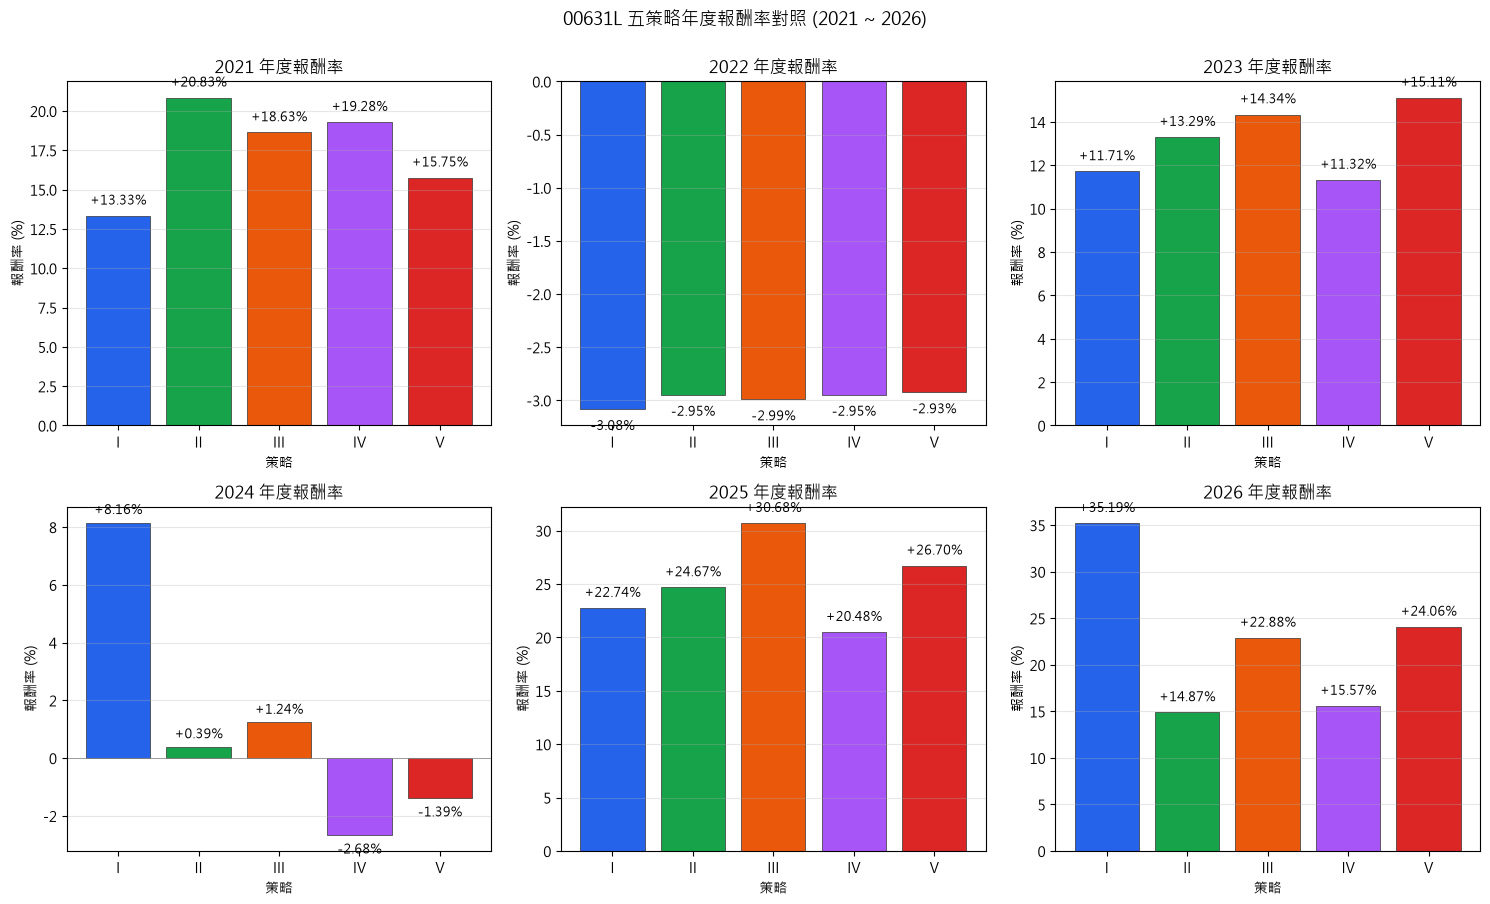

In [8]:
STRATEGY_COLORS = {
    'I':   '#2563eb',  # blue
    'II':  '#16a34a',  # green
    'III': '#ea580c',  # orange
    'IV':  '#a855f7',  # purple
    'V':   '#dc2626',  # red
}

n_years = len(YEARS)
n_cols = 3
n_rows = (n_years + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.5 * n_rows), sharey=False)
axes_flat = list(axes.flatten()) if n_years > 1 else [axes]

for ax, year in zip(axes_flat, YEARS):
    vals = [results.get((year, s), {}).get('return_pct', 0) for s in strategies_all]
    colors = [STRATEGY_COLORS[s] for s in strategies_all]
    bars = ax.bar(strategies_all, vals, color=colors, edgecolor='#333', linewidth=0.5)
    ymax = max(vals) if vals else 1
    ymin = min(vals) if vals else -1
    span = max(abs(ymax), abs(ymin), 1)
    for bar, v in zip(bars, vals):
        offset = span * 0.03
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + (offset if v >= 0 else -offset),
                f"{v:+.2f}%",
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(f"{year} 年度報酬率", fontsize=12)
    ax.set_ylabel("報酬率 (%)")
    ax.set_xlabel("策略")

# 隱藏多餘 subplot
for ax in axes_flat[n_years:]:
    ax.axis('off')

plt.suptitle("00631L 五策略年度報酬率對照 (2021 ~ 2026)", fontsize=13, y=1.00)
plt.tight_layout()
plt.show()


## 7. 圖表：五策略資本淨值走勢對照

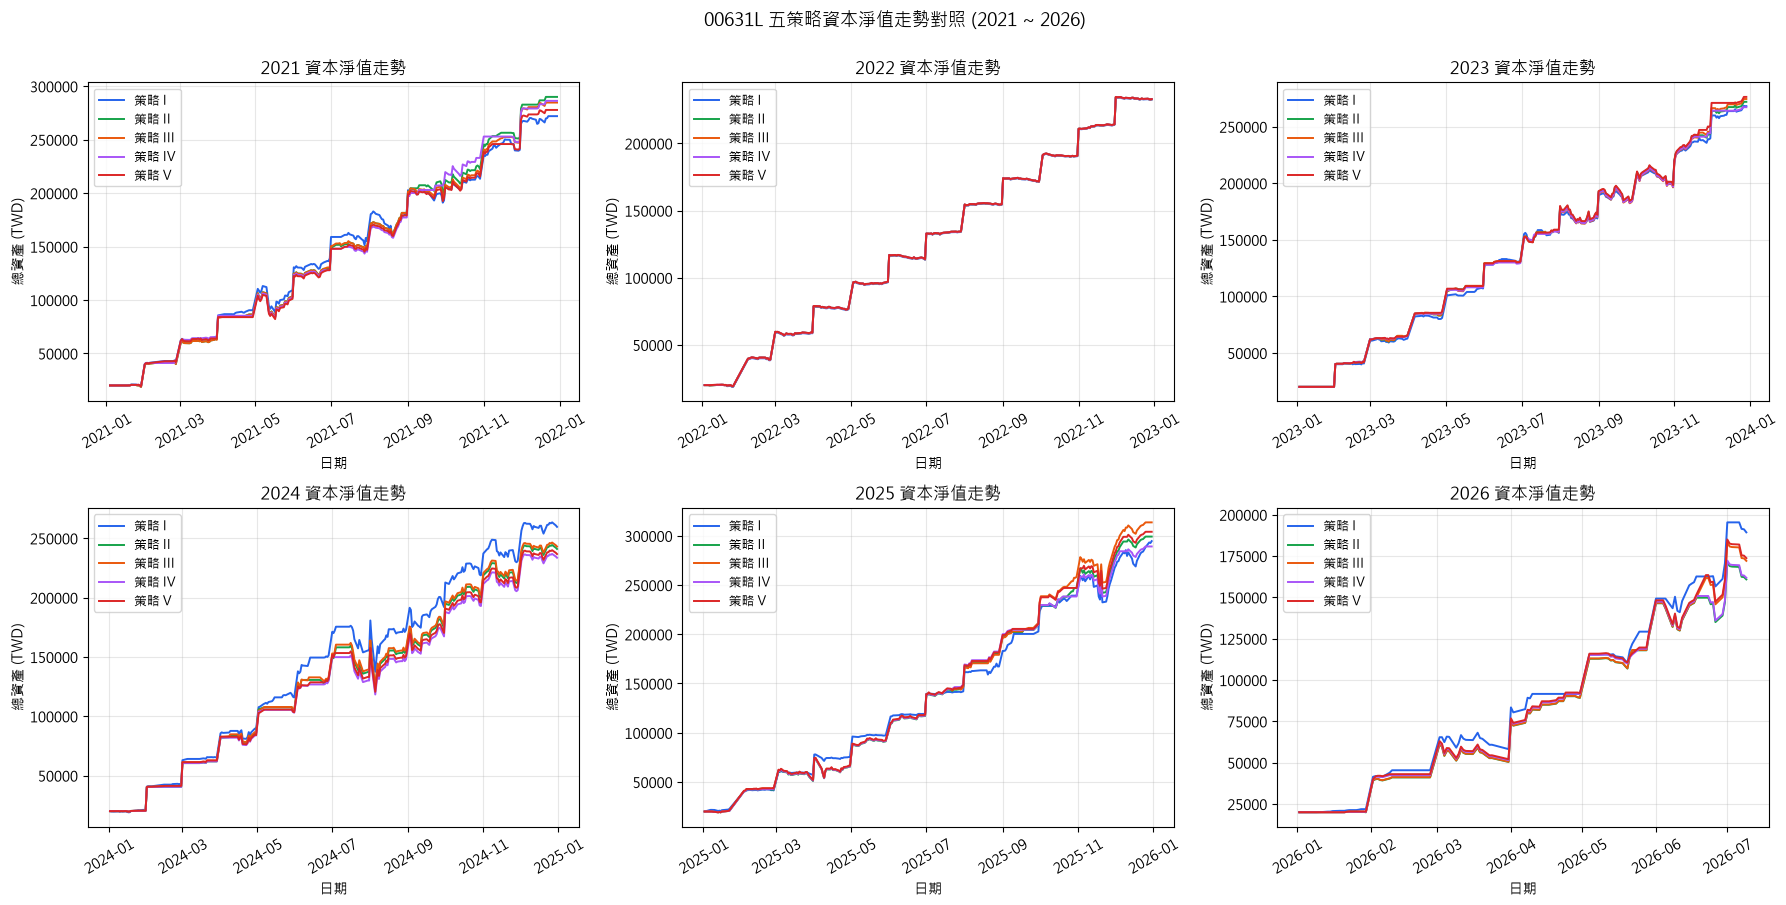

In [9]:
n_years = len(YEARS)
n_cols = 3
n_rows = (n_years + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows), sharey=False)
axes_flat = list(axes.flatten()) if n_years > 1 else [axes]

for ax, year in zip(axes_flat, YEARS):
    for s in strategies_all:
        if (year, s) not in results:
            continue
        daily = results[(year, s)]['daily']
        ax.plot(daily['date'], daily['total_assets'],
                label=f"策略 {s}", color=STRATEGY_COLORS[s], linewidth=1.4)
    ax.set_title(f"{year} 資本淨值走勢", fontsize=12)
    ax.set_xlabel("日期")
    ax.set_ylabel("總資產 (TWD)")
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

for ax in axes_flat[n_years:]:
    ax.axis('off')

plt.suptitle("00631L 五策略資本淨值走勢對照 (2021 ~ 2026)", fontsize=13, y=1.00)
plt.tight_layout()
plt.show()


## 8. 單一策略明細（可切換 inspect_year / inspect_strat 檢視）

In [10]:
inspect_year = 2025
inspect_strat = 'III'
r = results.get((inspect_year, inspect_strat))
if r is not None:
    print(f"=== {inspect_year} 策略 {inspect_strat} ===")
    print(f"入金 {r['total_deposits']:,.0f} · 期末總資產 {r['end_total_assets']:,.2f} · 報酬 {r['return_pct']:+.2f}%")
    print(f"進出場 {len(r['trades'])} 筆 · 完成輪次 {len(r['rounds'])} 輪")


=== 2025 策略 III ===
入金 240,000 · 期末總資產 313,632.88 · 報酬 +30.68%
進出場 36 筆 · 完成輪次 15 輪


In [11]:
# 交易明細
if r is not None:
    print("交易明細:")
    display(pd.DataFrame(r['trades']))


交易明細:


,date,action,price,invested,capital_after,drop_pct_today
0,2025-01-08,BUY_TRANCHE_1,11.290909,10000.000000,10000.000000,2.223972
1,2025-01-13,BUY_TRANCHE_2,10.409091,10000.000000,0.000000,4.702455
2,2025-01-22,SELL_ALL,11.404545,-21056.976000,21056.976000,-2.554670
3,2025-02-03,BUY_TRANCHE_1,10.431818,20528.488000,20528.488000,8.529295
4,2025-02-03,BUY_TRANCHE_2,10.431818,20528.488000,0.000000,8.529295
5,2025-02-05,SELL_ALL,10.893182,-42872.785614,42872.785614,-3.902016
6,2025-02-10,BUY_TRANCHE_1,10.945455,21436.392807,21436.392807,1.674153
7,2025-02-18,SELL_ALL,11.297727,-22126.309934,43562.702741,-0.893038
8,2025-02-24,BUY_TRANCHE_1,11.225000,21781.351371,21781.351371,1.397485
9,2025-03-03,BUY_TRANCHE_2,10.429545,41781.351371,0.000000,3.774376


In [12]:
# 完成輪次
if r is not None:
    print("完成輪次:")
    display(pd.DataFrame(r['rounds']))


完成輪次:


,entry_date,exit_date,total_invested,total_proceeds,entry_avg_cost,exit_price,pnl,pnl_pct
0,2025-01-08,2025-01-22,20000.000000,21056.976000,10.832083,11.404545,1056.976000,0.052849
1,2025-02-03,2025-02-05,41056.976000,42872.785614,10.431818,10.893182,1815.809614,0.044227
2,2025-02-10,2025-02-18,21436.392807,22126.309934,10.945455,11.297727,689.917127,0.032184
3,2025-02-24,2025-07-31,63562.702741,66276.322654,10.689115,11.145455,2713.619913,0.042692
4,2025-08-01,2025-08-07,83138.161327,87383.073674,10.950000,11.509091,4244.912347,0.051059
5,2025-08-20,2025-08-25,170521.235001,179128.530260,11.211364,11.777273,8607.295260,0.050476
6,2025-08-28,2025-09-09,89564.265130,93396.814640,11.790909,12.295455,3832.549510,0.042791
7,2025-09-17,2025-09-22,101480.539885,104968.822210,12.959091,13.404545,3488.282325,0.034374
8,2025-09-26,2025-10-02,206449.362096,218601.827567,13.165909,13.940909,12152.465471,0.058864
9,2025-10-08,2025-10-16,119300.913783,124788.349341,14.675000,15.350000,5487.435557,0.045997


## 觀察方向

1. **策略 I 是 MA-based baseline**：跨年表現穩定、觸發次數中等
2. **策略 II / III 進場門檻寬（1%/3%）** → 觸發次數多、抓小波段
3. **策略 IV / V 進場門檻嚴（1.5%/3.5%）** → 觸發次數少但單筆成功率相對高
4. **出場門檻 +2% (II, IV) vs +3% (III, V)**：+3% 的組合通常有較高單輪利潤，但可能被套住更久
5. **2024 vs 2025 vs 2026**：2024 震盪不利短波段、2025 多頭最有利、2026 上半年趨勢明顯（分割後）

改 `inspect_year` / `inspect_strat` 可以看單一年、單一策略的完整交易時間軸。
